# TQQQ vs QQQ TV-Match Backtest Lab

Compare strict `momentum_tv_match` long-only backtest outputs for `QQQ` and `TQQQ`.

- Source artifacts: `out/backtests/tv_match/*`
- Strategy engine: `scripts/strategies/backtest_tv_match.py`
- Expected workflow:
  1. Fetch or derive OHLC data
  2. Run `momentum_strategy_tv_match`
  3. Run `backtest_tv_match`


In [1]:
from pathlib import Path
import csv
from datetime import date, timedelta

import matplotlib.pyplot as plt

OUT_ROOT = Path("out")
SYMBOLS = ["QQQ", "TQQQ"]
TIMEFRAME = "daily"  # daily | weekly | monthly
MODE = "long_only"
YEARS_TO_PLOT = 5


def resolve_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / OUT_ROOT).exists():
            return candidate
    raise FileNotFoundError("Could not find repo root with out/")


def load_rows(path: Path) -> list[dict[str, str]]:
    with path.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        rows = list(reader)
    if not rows:
        raise ValueError(f"No rows found in {path}")
    return rows


def parse_float(value: str | None) -> float | None:
    raw = (value or "").strip()
    if not raw:
        return None
    return float(raw)


repo = resolve_repo_root()
backtest_dir = repo / OUT_ROOT / "backtests" / "tv_match"
comparison_stem = f"comparison_{TIMEFRAME}_{MODE}_{'_'.join(SYMBOLS)}"
comparison_csv = backtest_dir / f"{comparison_stem}.csv"

if not comparison_csv.exists():
    joined = ','.join(SYMBOLS)
    raise FileNotFoundError(
        f"Missing comparison summary: {comparison_csv}. Run: "
        f"python3 -m scripts.strategies.backtest_tv_match --symbols {joined} --timeframe {TIMEFRAME} --mode {MODE}"
    )

comparison_rows = load_rows(comparison_csv)
equity_by_symbol: dict[str, list[dict[str, str]]] = {}
for symbol in SYMBOLS:
    equity_path = backtest_dir / f"{symbol}_{TIMEFRAME}_{MODE}_equity.csv"
    if not equity_path.exists():
        raise FileNotFoundError(f"Missing equity file: {equity_path}")
    equity_by_symbol[symbol] = load_rows(equity_path)

comparison_rows


[{'Symbol': 'QQQ',
  'Mode': 'long_only',
  'InitialCapital': '100000.00',
  'EndingEquity': '1536854.44',
  'TotalReturnPct': '1436.8544',
  'Trades': '303',
  'ClosedTrades': '151',
  'WinRatePct': '51.66',
  'MaxDrawdownPct': '47.4193',
  'LastDate': '2026-05-15'},
 {'Symbol': 'TQQQ',
  'Mode': 'long_only',
  'InitialCapital': '100000.00',
  'EndingEquity': '8277520.38',
  'TotalReturnPct': '8177.5204',
  'Trades': '161',
  'ClosedTrades': '80',
  'WinRatePct': '51.25',
  'MaxDrawdownPct': '56.8118',
  'LastDate': '2026-05-15'}]

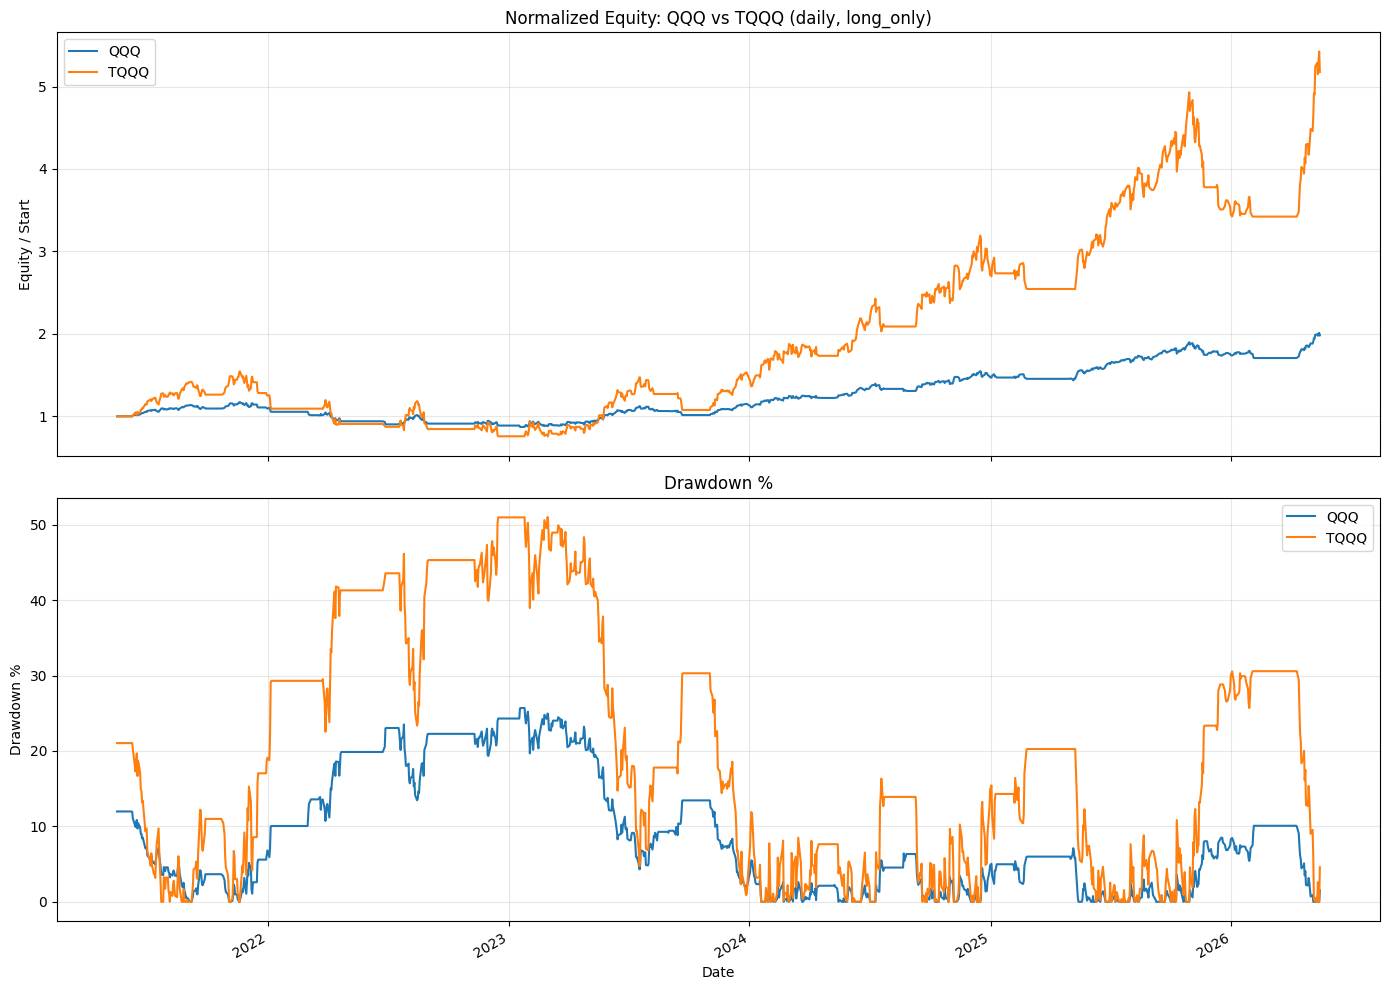

Summary
QQQ: ending=1536854.44 return=1436.8544% max_dd=47.4193% trades=303 win_rate=51.66%
TQQQ: ending=8277520.38 return=8177.5204% max_dd=56.8118% trades=161 win_rate=51.25%


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
start_cutoff = None
if YEARS_TO_PLOT is not None:
    latest_date = max(date.fromisoformat(rows[-1]["Date"]) for rows in equity_by_symbol.values())
    start_cutoff = latest_date - timedelta(days=365 * YEARS_TO_PLOT)

for symbol, rows in equity_by_symbol.items():
    dates = []
    equity = []
    drawdown = []
    for row in rows:
        row_date = date.fromisoformat(row["Date"])
        if start_cutoff is not None and row_date < start_cutoff:
            continue
        row_equity = parse_float(row.get("Equity"))
        row_drawdown = parse_float(row.get("DrawdownPct"))
        if row_equity is None or row_drawdown is None:
            continue
        dates.append(row_date)
        equity.append(row_equity)
        drawdown.append(row_drawdown)

    if not equity:
        continue

    baseline = equity[0]
    normalized = [value / baseline for value in equity]
    axes[0].plot(dates, normalized, linewidth=1.5, label=symbol)
    axes[1].plot(dates, drawdown, linewidth=1.5, label=symbol)

axes[0].set_title(f"Normalized Equity: {' vs '.join(SYMBOLS)} ({TIMEFRAME}, {MODE})")
axes[0].set_ylabel("Equity / Start")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best")

axes[1].set_title("Drawdown %")
axes[1].set_ylabel("Drawdown %")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("Summary")
for row in comparison_rows:
    print(
        f"{row['Symbol']}: ending={row['EndingEquity']} return={row['TotalReturnPct']}% "
        f"max_dd={row['MaxDrawdownPct']}% trades={row['Trades']} win_rate={row['WinRatePct']}%"
    )
